In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from Floquet_perturbation_theory import *
from helper_function import *
from utils import *
from scipy.optimize import root

s = Simulation()
N_t = 3000
tg = 250
toffset = 50
tlist = np.linspace(0, tg, N_t)
tlist_ext = np.linspace(0, tg + 2*toffset, N_t)
sigma = 0.1

# compute cos params
cos_amp, cos_wd = compute_cos_params(s, tg)
heff_params = s.heff(cos_wd, cos_amp)
Delta = heff_params[2][2] - heff_params[0][0]
# rrr follows from the heff response to amplitude, as both Omega_ab and Omega_bc are linear rrr is constant for all amp- and wd values
rrr = heff_params[1][2] / heff_params[0][1] # compute the RabiRateRatio (RRR) from the two rabirates in cos drive case

In [3]:
# with a given gate time we compute the fidelity for cos drive and drag drive
def compute_htarget(tg, use_drag=True):
    ht, ht_args = h_target(Delta, rrr, tg, sigma_r=sigma,pulse='tanh')
    return ht, ht_args
ht, args = compute_htarget(tg)

/Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


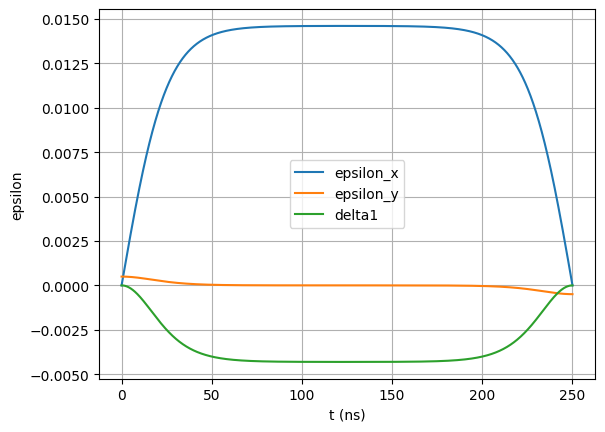

In [4]:
ex = np.array([args[0](t) for t in tlist])
ey = np.array([args[1](t) for t in tlist])
d1 = np.array([args[2](t) for t in tlist])
plt.figure()
plt.plot(tlist, ex, label='epsilon_x')
plt.plot(tlist, ey, label='epsilon_y')
plt.plot(tlist, d1, label='delta1')
plt.xlabel('t (ns)')
plt.ylabel('epsilon')
plt.legend()
plt.grid(True)
plt.show()

To check gate fidelity with target hamiltonian, we sweep tg and compute Delta and rrr accordingly


Also we use a normal effective hamiltonian for cos drive to compensate compare

In [5]:
import pickle
from pathlib import Path
ROOT = Path.cwd()
# Define the directory for saving coefficients
coeff_dir = ROOT / 'operational_res'
coeff_dir.mkdir(parents=True, exist_ok=True)
coeff_file = coeff_dir / 'heff_coefficients.pkl'
wd_range = [0.7 * 2*np.pi, 0.712 * 2*np.pi] # TODO anpassen
amp_real_max = 1.0 * 2 * np.pi
amp_imag_max = amp_real_max / 8
amp_real_range = (-amp_real_max, amp_real_max)
amp_imag_range = (-amp_imag_max, amp_imag_max)

# Load coefficients
with open(coeff_file, 'rb') as f:
    coefficients_data = pickle.load(f)
coeffs01 = coefficients_data['coeffs01']
coeffs00 = coefficients_data['coeffs00']
coeffs11 = coefficients_data['coeffs11']
# coeffs12 = coefficients_data['coeffs12']
coeffs22 = coefficients_data['coeffs22']
# coeffs02 = coefficients_data['coeffs02']
print(f"Coefficients loaded from {coeff_file}")

def heff_fit(coeffs, wd, amp):
    ar, ai = np.real(amp), np.imag(amp)
    x = [1, wd, ar, ai, wd**2, ar**2, ai**2,
                wd*ar, wd*ai, ar*ai]
    if not len(coeffs) == 10:
        x.extend([
            wd**3, ar**3, ai**3,
            wd**2*ar, wd**2*ai,
            wd*ar**2, wd*ai**2,
            ar**2*ai, ar*ai**2,
            wd*ar*ai])
    return np.array(x) @ coeffs

Coefficients loaded from /Users/florianmaier/Library/CloudStorage/OneDrive-TUM/ba/quantum_information_ba/TransmonCouplerSimulation/operational_res/heff_coefficients.pkl


setup the functions that are used to optimize the 3 independent parameters wd, amp_r and amp_i for achieving max compliance with the target hamiltonian. 

In [6]:
from scipy.optimize import least_squares

def find_parameter_change_fit(wd0, heff_t, prev_solution):
    if not prev_solution:
        prev_solution = [0,0,0]
    def residuals(x):
        dw, ar, ai = x
        wd = wd0 + dw
        amp = ar + 1j*ai 

        deltadiff = (heff_fit(coeffs00, wd, amp) - heff_fit(coeffs11, wd, amp)) - (heff_t[0,0] - heff_t[1,1])
        # deltadiff2 = (heff_fit(coeffs11, wd, amp) - heff_fit(coeffs22, wd, amp)) - (heff_t[1,1] - heff_t[2,2])
        omega_diff = heff_fit(coeffs01, wd, amp) - heff_t[0,1]

        weights = np.array([1,
                            1,
                            1,])
        return weights*np.array([
            abs(deltadiff),
            np.real(omega_diff),
            np.imag(omega_diff)])
    dwd_range = (-1,1)
    res = least_squares(residuals, x0=[prev_solution[0], prev_solution[1], prev_solution[2]], 
                        bounds=([wd_range[0] - cos_wd, amp_real_range[0], amp_imag_range[0]], 
                                [wd_range[1] - cos_wd, amp_real_range[1], amp_imag_range[1]]))
    return {"dw": res.x[0], "dar": res.x[1], "dai": res.x[2]}

# define a function to change the list representation of h_target to one time dependant matrix function
def sum_list(ht):
    def f(t):
        result = ht[0]
        for i in range(1, len(ht)):
            result = result + ht[i][0] * ht[i][1](t)
        return result
    return f

drive_signal_func gives the time dependant DRAG amplitude 

mesolve cannot deal with the difficult heff_modulated / pulse_shape_modulated functions as a parameter, so instead we precompute values and then simply interpolate between the defined values.

In [7]:
# test difference between direct and perfect simulation
ht, _ = compute_htarget(tg)
ht_func = sum_list(ht)

def compute_pulse_shape(tlist, ht_func):
    prev_sol = None
    drive_freq_precomputed = []
    drive_amp_real_precomputed = []
    drive_amp_imag_precomputed = []
    for t in (tlist):
        res = find_parameter_change_fit(cos_wd, ht_func(t), prev_solution=prev_sol)
        freq= cos_wd + res['dw']
        amp_real = res['dar']
        amp_imag = res['dai']
        drive_freq_precomputed.append(freq)
        drive_amp_real_precomputed.append(amp_real)
        drive_amp_imag_precomputed.append(amp_imag)
        prev_sol = [res['dw'], amp_real, amp_imag]
    return np.array(drive_freq_precomputed), np.array(drive_amp_real_precomputed), np.array(drive_amp_imag_precomputed)

drive_freq_precomputed, drive_amp_real_precomputed, drive_amp_imag_precomputed = compute_pulse_shape(tlist, ht_func)
heff_data = {
'frequency': drive_freq_precomputed,
'amplitude_real': drive_amp_real_precomputed,
'amplitude_imag': drive_amp_imag_precomputed
}

In [8]:
def drive_signal_interp(t, freq = drive_freq_precomputed, amp_real = drive_amp_real_precomputed, amp_imag = drive_amp_imag_precomputed):
    if t <= tlist[0]:
        return [freq[0],0]
    if t >= tlist[-1]:
        return [freq[-1],0]
    idx = np.searchsorted(tlist, t) - 1
    t0 = tlist[idx]
    t1 = tlist[idx + 1]
    alpha = (t - t0) / (t1 - t0)
    ar = (1 - alpha) * amp_real[idx] + alpha * amp_real[idx + 1]
    ai = (1 - alpha) * amp_imag[idx] + alpha * amp_imag[idx + 1]
    wd = (1 - alpha) * freq[idx] + alpha * freq[idx + 1]
    return [wd, ar + 1j*ai]

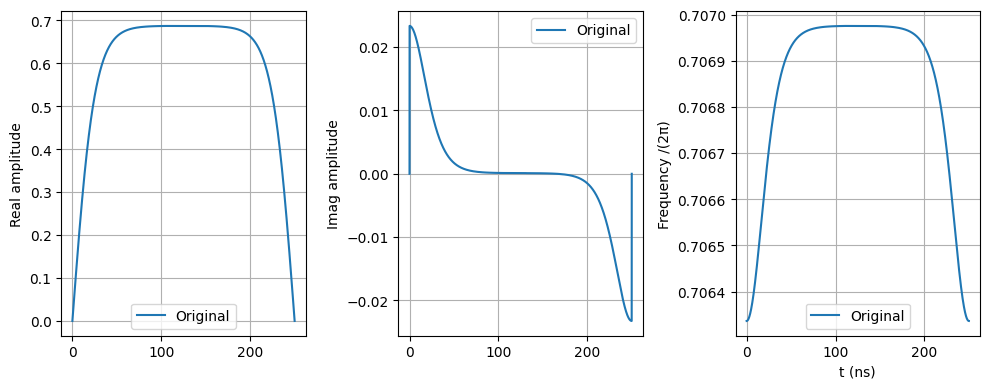

In [9]:
def plot_drive_components_with_fit(t_end=tg, n=2000):
    amp_real = np.array([drive_signal_interp(t)[1].real for t in tlist])
    amp_imag = np.array([drive_signal_interp(t)[1].imag for t in tlist])
    freq = np.array([drive_signal_interp(t)[0] for t in tlist])

    _, axes = plt.subplots(1,3,figsize=(10,4))

    axes[0].plot(tlist, amp_real, label="Original")
    axes[0].set_ylabel("Real amplitude")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(tlist, amp_imag, label="Original")
    axes[1].set_ylabel("Imag amplitude")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(tlist, freq/(2*np.pi), label="Original")
    axes[2].set_ylabel("Frequency /(2π)")
    axes[2].set_xlabel("t (ns)")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

plot_drive_components_with_fit()

with the heff_modulated_interp function, the extraction of fidelity measurements can be done fast. To test for the right adoption of h_target, we compare fidelities for h_t, h_modulated and the raw hamiltonian with the given drive signal (h_drive). In the following those 3 cases will correspond to the values fid_engineered, fid_modulated, fid_drive.

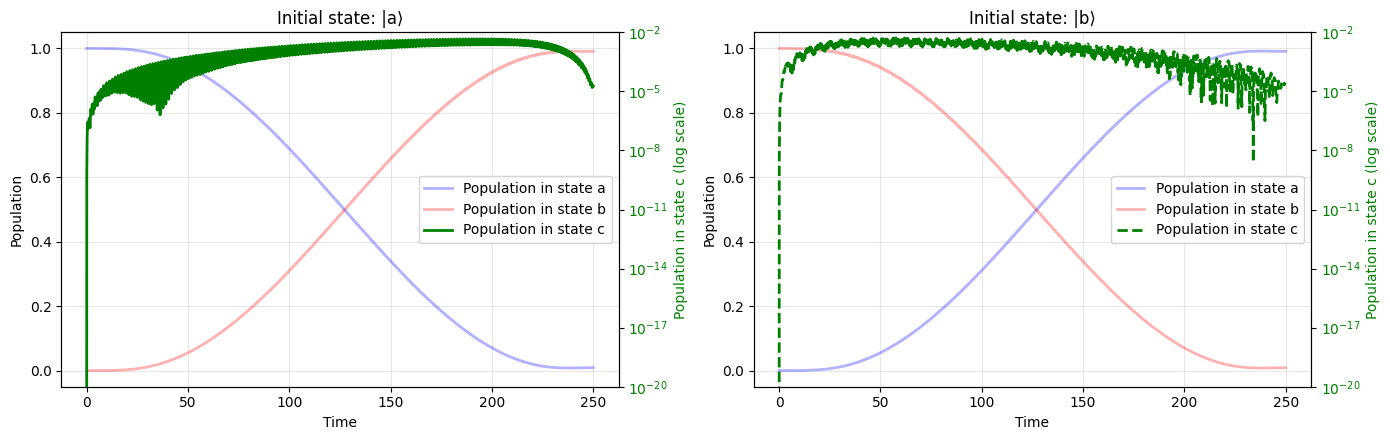

infidelity driven: pop: 9.19e-03


In [10]:
# simulate the result directly over H0 and V1 from s 
def signal(t, args=None):
    s = drive_signal_interp(t)
    return np.real(s[1]) * np.cos(s[0]*t) - np.imag(s[1]) * np.sin(s[0]*t)
lh = [s.H0, [s.V1, signal]]
f_d = extract_fidelity(lh, tlist, s=s)
fpop_d = extract_pop_fid(lh, tlist, plot=True, plot_c=True, s=s)['iswap_fidelity']
print(f"infidelity driven: pop: {(1-fpop_d):.2e}")

In [15]:
def shifted_drive_signal(t, shift):
    wd, amp = drive_signal_interp(t)
    return np.real(amp) * np.cos((wd + shift) * t) - np.imag(amp) * np.sin((wd + shift) * t)

def compute_pop_fidelity_for_shift(shift):
    h_shift = [s.H0, [s.V1, lambda t, args=None, shift=shift: shifted_drive_signal(t, shift)]]
    result = extract_pop_fid(h_shift, tlist, s=s, plot=False, plot_c=False)
    return result['iswap_fidelity']

def find_optimal_frequency_shift(shift_range=(-0.01 * 2*np.pi, 0.01 * 2*np.pi), n=30):
    shifts = np.linspace(shift_range[0], shift_range[1], n)
    fidelities = [compute_pop_fidelity_for_shift(shift) for shift in tqdm(shifts)]
    best_index = int(np.argmax(fidelities))
    return {
        'shift': shifts[best_index],
        'fidelity': fidelities[best_index],
        'shifts': shifts,
        'fidelities': np.array(fidelities)
    }

# Beispielaufruf
opt_result = find_optimal_frequency_shift()
print(f"optimaler Frequenzshift: {opt_result['shift']:.4e}, Fidelity: {opt_result['fidelity']:.6f}")

100%|██████████| 30/30 [00:35<00:00,  1.19s/it]

optimaler Frequenzshift: 2.1666e-03, Fidelity: 0.993544


In [ ]:
from tqdm import tqdm


def build_drive_signal_interp(tlist_local, freq_arr, amp_real_arr, amp_imag_arr):
    def drive_signal_interp_local(t):
        if t <= tlist_local[0]:
            return [freq_arr[0], amp_real_arr[0] + 1j * amp_imag_arr[0]]
        if t >= tlist_local[-1]:
            return [freq_arr[-1], amp_real_arr[-1] + 1j * amp_imag_arr[-1]]

        idx = np.searchsorted(tlist_local, t) - 1
        t0 = tlist_local[idx]
        t1 = tlist_local[idx + 1]
        alpha = (t - t0) / (t1 - t0)

        ar = (1 - alpha) * amp_real_arr[idx] + alpha * amp_real_arr[idx + 1]
        ai = (1 - alpha) * amp_imag_arr[idx] + alpha * amp_imag_arr[idx + 1]
        wd = (1 - alpha) * freq_arr[idx] + alpha * freq_arr[idx + 1]

        return [wd, ar + 1j * ai]

    return drive_signal_interp_local


def shifted_drive_signal_from_interp(drive_signal_interp_local, t, shift):
    wd, amp = drive_signal_interp_local(t)
    return np.real(amp) * np.cos((wd + shift) * t) - np.imag(amp) * np.sin((wd + shift) * t)


def optimize_shift_for_gate_times(gate_times, shift_range=(-0.01 * 2 * np.pi, 0.01 * 2 * np.pi), n_shifts=30):
    results = []

    for tg_i in tqdm(gate_times, desc="Scanning gate times"):
        tlist_i = np.linspace(0, tg_i, N_t)
        ht_i, _ = compute_htarget(tg_i)
        ht_func_i = sum_list(ht_i)

        freq_arr, amp_real_arr, amp_imag_arr = compute_pulse_shape(tlist_i, ht_func_i)
        drive_signal_interp_i = build_drive_signal_interp(tlist_i, freq_arr, amp_real_arr, amp_imag_arr)

        def shifted_drive_signal_local(t, shift, interp=drive_signal_interp_i):
            return shifted_drive_signal_from_interp(interp, t, shift)

        def compute_pop_fidelity_for_shift_local(shift):
            h_shift = [
                s.H0,
                [s.V1, lambda t, args=None, shift=shift: shifted_drive_signal_local(t, shift)]
            ]
            result = extract_pop_fid(h_shift, tlist_i, s=s, plot=False, plot_c=False)
            return result["iswap_fidelity"]

        shifts = np.linspace(shift_range[0], shift_range[1], n_shifts)
        fidelities = np.array([
            compute_pop_fidelity_for_shift_local(shift)
            for shift in tqdm(shifts, desc=f"Optimizing shift for tg={tg_i}", leave=False)
        ])
        best_index = int(np.argmax(fidelities))

        results.append({
            "tg": tg_i,
            "shift": shifts[best_index],
            "fidelity": fidelities[best_index],
            "shifts": shifts,
            "fidelities": fidelities,
        })

    return results


gate_times = np.array([300, 400, 500, 600, 700, 800, 900])
results = optimize_shift_for_gate_times(gate_times)

fidelities = np.array([res["fidelity"] for res in results])
shifts = np.array([res["shift"] for res in results])

plt.figure(figsize=(7, 3))
plt.plot(gate_times, fidelities, marker="o")
plt.xlabel("Gate time tg")
plt.ylabel("Optimal iswap fidelity")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3))
plt.plot(gate_times, shifts / (2 * np.pi), marker="o")
plt.xlabel("Gate time tg")
plt.ylabel("Optimal frequency shift / (2π)")
plt.grid(True)
plt.tight_layout()
plt.show()


ValueError: Function to integrate must not return a tuple.

Before moving on with the investigation fo the unitary transformations. Let's verify, that Floquet Theory can't predict the detune effect, observed in the direct simulation. The expectation is for the detune to be absent with the floquet prediction, because population exchange in the sambe space doesn't show any such problems. Thus the normal population, which is directly proportional at $t=t_g$ should follow this example. 

3000it [00:31, 94.26it/s]


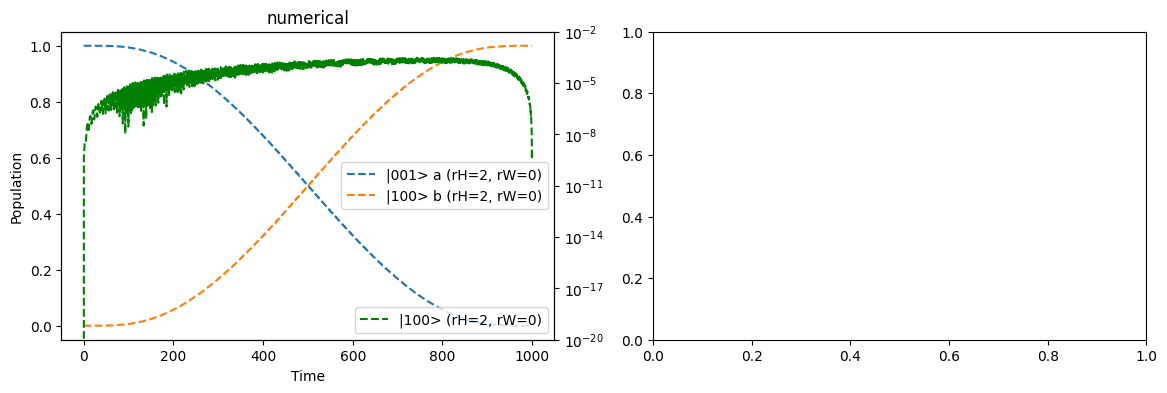

In [ ]:
initial_state = np.zeros(27)
initial_state[s.state_a] = 1
psi_t_rHeff2_rW0_num, lUnum = Psi_t_FloquetPerturb_dynamic(2,1, drive_signal_interp,
    s.resonances, s.E_array,s.V1_dressed_array,initial_state,tlist,num = True)


# each column in the unitary represents one initial state U(row;column)
def plot_states(states, names=None):
    _, axes = plt.subplots(1,2, figsize = (14,4))
    for i, psi in enumerate(states): 
        title = '' if names is None else names[i]

        axes[i].plot(tlist, np.abs(psi[s.state_a, :]) ** 2, "--",label="|001> a (rH=2, rW=0)",)
        axes[i].plot(tlist, np.abs(psi[s.state_b, :]) ** 2, "--",label="|100> b (rH=2, rW=0)",)
        axes[i].set_xlabel('Time')
        axes[i].set_ylabel('Population')
        axes[i].set_title(title)
        axes[i].legend()
        # plot the leakage population on a log-scale
        axc = axes[i].twinx()
        axc.semilogy(tlist, np.abs(psi[s.state_c, :]) ** 2, "--",label="|100> (rH=2, rW=0)",color = 'green')
        axc.set_ylim([1e-20, 1e-2])
        # axc.semilogy(tlist, np.abs(lU[:,2,i])**2, label='population c (log)', color='green')
        axc.legend()
        axc.plot()
plot_states([psi_t_rHeff2_rW0_num], ['numerical'])

NameError: name 'lUad' is not defined

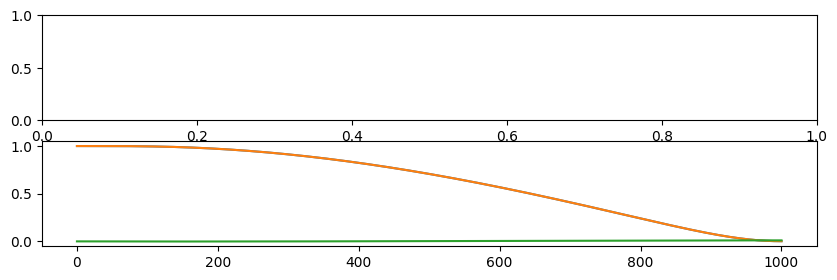

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 3))

# show the unitary evolution at 00, 11 and 01 for the target evolution and the actual evolution
axes[1].plot(tlist, lUnum[0,0,:], label="00num")
axes[1].plot(tlist, lUnum[1,1,:], label="11num")
axes[1].plot(tlist, lUnum[0,1,:], label="01num")
axes[0].plot(tlist, lUad[0,0,:], label="00ad")
axes[0].plot(tlist, lUad[1,1,:], label="11ad")
axes[0].plot(tlist, lUad[0,1,:], label="01ad")
axes[1].legend()
axes[0].legend()
# axes[0].plot(tlist, ud_01, label="ud_01")
# axes[1].plot(tlist, uf_00-uf_11, label="uf_delta")
# axes[1].plot(tlist, uf_01, label="uf_01")

def demodulated_amplitude(signal, t_vals):
    wd_vals = np.array([drive_wd_interp(t) for t in t_vals])
    phi = np.zeros_like(t_vals)
    phi[1:] = np.cumsum(0.5 * (wd_vals[:-1] + wd_vals[1:]) * np.diff(t_vals))
    envelope = signal * np.exp(1j * phi)
    return np.sqrt(np.real(envelope)**2 + np.imag(envelope)**2)

# ud_delta = ud_00 - ud_11
# am_ud_delta = demodulated_amplitude(ud_delta, tlist_fid)
# am_ud_01 = demodulated_amplitude(ud_01, tlist_fid)

# axes[2].plot(tlist, ud_01-uf_01, label='amplitude deviance rr')
# axes[2].plot(tlist, (ud_00-ud_11)-(uf_00-uf_11), label='amplitude deviance dd')
# ax_amp.plot(tlist_fid, am_ud_delta, label='amplitude(ud_00-ud_11)')
# ax_amp.plot(tlist_fid, am_ud_01, label='amplitude(ud_01)')
plt.show()


In the direct simulation, maximum fidelity can only be reached by only including state_a and b in the resonant subspace to compute the cosine pulse parameters. Let's see if the numerical dynamic perturbation theory can predict correctly the population transfer in both cases: cos_amp and cos_amp_full. 

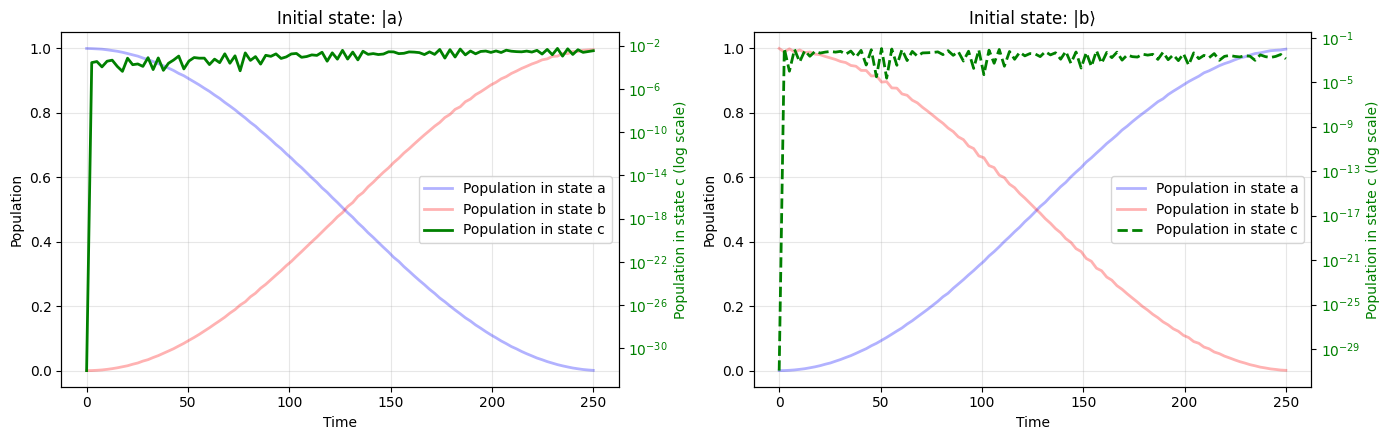

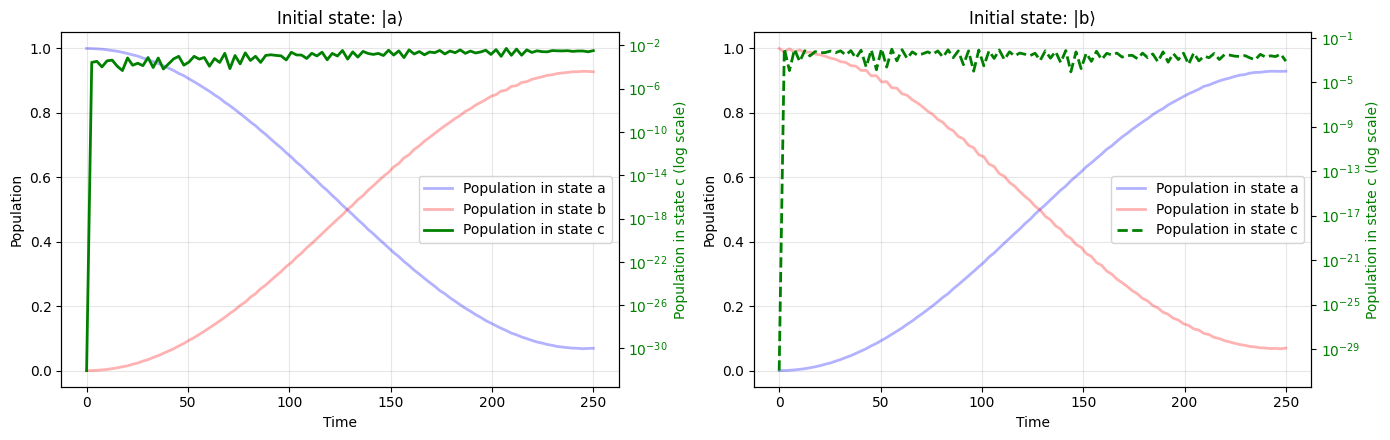

100it [00:01, 91.49it/s]
100it [00:01, 91.58it/s]


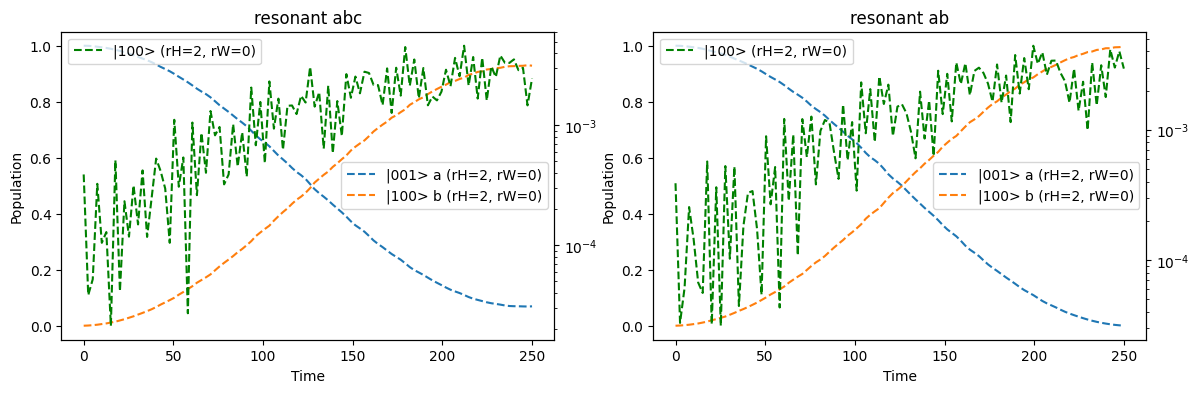

In [ ]:
cos_amp_full, cos_wd_full = compute_cos_params(s, tg, use_c = True)
# verify that drag improves the engineered outcome
h_cos = [s.H0, [s.V1, lambda t, args: cos_amp * np.cos(cos_wd * t)]]
fpop_e_nodrag = extract_pop_fid(h_cos, tlist, s=s, plot=True, plot_c = True)
# print(f"infidelity cos drive direct: {(1-fpop_e_nodrag['iswap_fidelity']):.2e}")
h_cos = [s.H0, [s.V1, lambda t, args: cos_amp_full * np.cos(cos_wd_full * t)]]
fpop_e_nodrag = extract_pop_fid(h_cos, tlist, s=s, plot=True, plot_c = True)
# print(f"infidelity cos drive direct: {(1-fpop_e_nodrag['iswap_fidelity']):.2e}")

# now after plotting the difference, plot the floquet answer 
psi_cos_full, _ = Psi_t_FloquetPerturb_dynamic(2,1,
    lambda t: cos_wd_full,
    lambda t: cos_amp_full,
    s.resonances, s.E_array,s.V1_dressed_array,initial_state,tlist,num = True,)
psi_cos, _ = Psi_t_FloquetPerturb_dynamic(2,1,
    lambda t: cos_wd,
    lambda t: cos_amp,
    s.resonances, s.E_array,s.V1_dressed_array,initial_state,tlist,num = True,)
plot_states([psi_cos_full, psi_cos], ['resonant abc', 'resonant ab'])

Those plots verify, that the off resonance because of wrong resonant subspace can in principle be predicted.

Let's verify, that no drive at all keeps the directly simulated population at same level. Also check the fidelity that the target hamiltonian simulated in sambe space reaches and compare it to the same simulation but without the drag pulse added.  

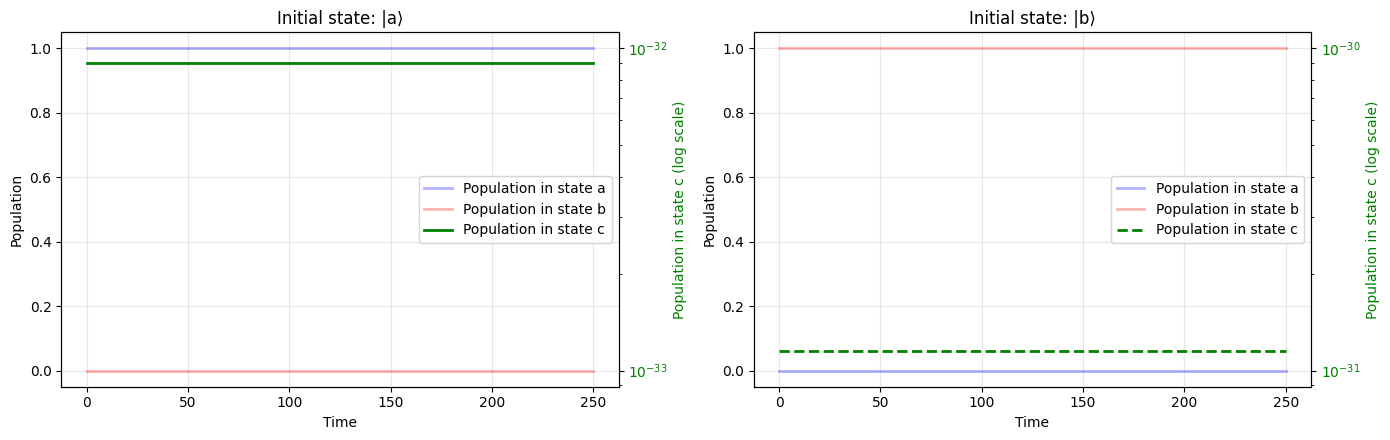

infidelity sambe space: 6.51e-01 pop: 3.21e-04
infidelity gauss no drag: 5.05e-01 pop: 3.08e-01


In [ ]:
#test without drive
h_test = [s.H0, 0]
fpop_e_nodrag = extract_pop_fid(h_test, tlist, s=s, plot=True, plot_c = True)
# sambe space simulation of target hamiltonian
f_e = extract_fidelity(ht, tlist)
fpop_e = extract_pop_fid(ht, tlist, plot=False)['iswap_fidelity']
print(f"infidelity sambe space: {(1-f_e):.2e} pop: {(1-fpop_e):.2e}")
# compare to a target hamiltonian without drag
ht_nodrag, args = compute_htarget(tg, use_drag=False)
f_e_nodrag = extract_fidelity(ht_nodrag, tlist)
fpop_e_nodrag = extract_pop_fid(ht_nodrag, tlist, plot=False)['iswap_fidelity']
print(f"infidelity gauss no drag: {(1-f_e_nodrag):.2e} pop: {(1-fpop_e_nodrag):.2e}")
